In [1]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import json
import csv
import seaborn as sns
import os

In [2]:
video_dir = Path('/tf/00_data/#_2021_Sleep_Video/')
ann_files = list(video_dir.glob('*/*.json'))
test_list_file = "data/kvss/A-test_set.txt"
valid_list_file = "data/kvss/A-valid_set.txt"
train_list_file = "data/kvss/A-train_set.txt"
def load_list(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    return [line.strip() for line in lines]
test_list = load_list(test_list_file)
valid_list = load_list(valid_list_file)
train_list = load_list(train_list_file)
all_list = test_list + valid_list + train_list
test_files = [f for f in ann_files if f.stem.replace('_annotation', '') in test_list]
ann_files = [f for f in ann_files if f.stem.replace('_annotation', '') in all_list]

In [4]:
sample = ann_files[0]
data = json.load(open(sample, 'r'))
print(data.keys())
print(data['Report'], data['Case_Info'])

dict_keys(['Case_Info', 'Report', 'Video_Info', 'Event'])
{'Sex': 'Male', 'Age': 73, 'BMI': 25.2, 'Time_in_Bed(TIB)': 447.5, 'Total_Sleep_Time(TST)': 356.5, 'Sleep_Efficiency': 79.7, 'Sleep_Latency': 5.0, 'REM_Latency': 67.5, 'Wake_after_Sleep_Onset(WASO)': 86.0, 'Total_Wake_Time(TWT)': 91.0, 'Ratio_of_TWT_to_TIB': 20.3, 'NREM_Time': 257.0, 'Ratio_of_NREM_Time_to_TIB': 57.4, 'Stage_1_Time': 87.0, 'Ratio_of_Stage_1_Time_to_TIB': 19.4, 'Stage_2_Time': 126.5, 'Ratio_of_Stage_2_Time_to_TIB': 28.3, 'Stage_3_Time': 43.5, 'Ratio_of_Stage_3_Time_to_TIB': 9.7, 'REM_Time': 99.5, 'Ratio_of_REM_Time_to_TIB': 22.2, 'Ratio_of_Snoring_Time_to_TST': 10.4, 'Obstructive_Apnea_Index_during_REM': 6.6, 'Obstructive_Apnea_Index_during_NREM': 2.3, 'Obstructive_Apnea_Index': 3.5, 'Central_Apnea_Index_during_REM': 0.0, 'Central_Apnea_Index_during_NREM': 11.4, 'Central_Apnea_Index': 8.2, 'Mixed_Apnea_Index_during_REM': 5.4, 'Mixed_Apnea_Index_during_NREM': 20.1, 'Mixed_Apnea_Index': 16.0, 'Hypopnea_Index_during

In [13]:
data['Report'].keys()

dict_keys(['Sex', 'Age', 'BMI', 'Time_in_Bed(TIB)', 'Total_Sleep_Time(TST)', 'Sleep_Efficiency', 'Sleep_Latency', 'REM_Latency', 'Wake_after_Sleep_Onset(WASO)', 'Total_Wake_Time(TWT)', 'Ratio_of_TWT_to_TIB', 'NREM_Time', 'Ratio_of_NREM_Time_to_TIB', 'Stage_1_Time', 'Ratio_of_Stage_1_Time_to_TIB', 'Stage_2_Time', 'Ratio_of_Stage_2_Time_to_TIB', 'Stage_3_Time', 'Ratio_of_Stage_3_Time_to_TIB', 'REM_Time', 'Ratio_of_REM_Time_to_TIB', 'Ratio_of_Snoring_Time_to_TST', 'Obstructive_Apnea_Index_during_REM', 'Obstructive_Apnea_Index_during_NREM', 'Obstructive_Apnea_Index', 'Central_Apnea_Index_during_REM', 'Central_Apnea_Index_during_NREM', 'Central_Apnea_Index', 'Mixed_Apnea_Index_during_REM', 'Mixed_Apnea_Index_during_NREM', 'Mixed_Apnea_Index', 'Hypopnea_Index_during_REM', 'Hypopnea_Index_during_NREM', 'Total_Hypopnea_Index', 'RERA_during_REM', 'RERA_during_NREM', 'RERA', 'AHI_during_REM', 'AHI_during_NREM', 'AHI', 'RDI_during_REM', 'RDI_during_NREM', 'RDI', 'Sleep_Time_in_the_Supine_Position

In [3]:
def build_df(ann_files, csv_path=None):
    records = []
    for f in ann_files:
        data = json.load(open(f, 'r'))
        metrics = pd.read_csv(csv_path)
        info = data['Case_Info']
        report = data['Report']
        cols_fairness = [
            # Demographic
            'Sex', 'Age', 'BMI',

            # Sleep structure
            'Time_in_Bed(TIB)', 'Total_Sleep_Time(TST)', 'Sleep_Efficiency',
            'Sleep_Latency', 'REM_Latency', 'Wake_after_Sleep_Onset(WASO)',
            'Total_Wake_Time(TWT)', 'NREM_Time', 'REM_Time',
            'Ratio_of_REM_Time_to_TIB', 'Ratio_of_NREM_Time_to_TIB',

            # Respiratory / OSA severity
            'Obstructive_Apnea_Index', 'Total_Hypopnea_Index', 'AHI', 'RDI',
            'Ratio_of_Saturation_below_90%',

            # Physiological / motion-related
            'Mean_Heart_Rate', 'PLM_Index', 'Total_Arousal_Index'
        ]
        record = {col: report.get(col, np.nan) for col in cols_fairness}
        record['subject'] = info['Case_Number']
        records.append(record)
    df = pd.DataFrame.from_records(records)
    df = df.merge(metrics, on='subject', how='left')
    return df
# stage1 = '/tf/01_code/mylittlecodes/SleepVST_baseline/movient_mamba_test/stage1_test_results/subject_metrics_4class.csv'
# df_with_stage1 = build_df(test_files, csv_path=stage1)
# print(df_with_stage1.head())

stage2 = '/tf/01_code/mylittlecodes/SleepVST_baseline/movient_mamba_test/stage2_test_results/subject_metrics_4class.csv'
df_with_stage2 = build_df(test_files, csv_path=stage2)
print(df_with_stage2.head())

      Sex   Age   BMI  Time_in_Bed(TIB)  Total_Sleep_Time(TST)  \
0  Female  56.0  26.5             433.0                  383.0   
1    Male  59.0  25.4             466.7                  379.0   
2  Female  53.0  21.8             425.0                  303.5   
3    Male  42.0  38.3             424.0                  379.0   
4    Male  58.0  25.7             395.5                  276.5   

   Sleep_Efficiency  Sleep_Latency  REM_Latency  Wake_after_Sleep_Onset(WASO)  \
0              88.5            9.5         93.0                          40.5   
1              81.2           10.5         65.5                          77.2   
2              71.4           17.0        173.0                         104.5   
3              89.4            9.0        314.5                          36.0   
4              69.9           49.5        224.0                          69.5   

   Total_Wake_Time(TWT)  ...  Total_Arousal_Index           subject  accuracy  \
0                  50.0  ...       

In [15]:
df_with_stage1.keys()

Index(['Sex', 'Age', 'BMI', 'Time_in_Bed(TIB)', 'Total_Sleep_Time(TST)',
       'Sleep_Efficiency', 'Sleep_Latency', 'REM_Latency',
       'Wake_after_Sleep_Onset(WASO)', 'Total_Wake_Time(TWT)', 'NREM_Time',
       'REM_Time', 'Ratio_of_REM_Time_to_TIB', 'Ratio_of_NREM_Time_to_TIB',
       'Obstructive_Apnea_Index', 'Total_Hypopnea_Index', 'AHI', 'RDI',
       'Ratio_of_Saturation_below_90%', 'Mean_Heart_Rate', 'PLM_Index',
       'Total_Arousal_Index', 'subject', 'accuracy', 'cohen_kappa',
       'precision_0', 'recall_0', 'f1-score_0', 'precision_1', 'recall_1',
       'f1-score_1', 'precision_2', 'recall_2', 'f1-score_2', 'precision_3',
       'recall_3', 'f1-score_3', 'macro_precision', 'macro_recall',
       'macro_f1'],
      dtype='object')

In [ ]:
df_with_stage1[df_with_stage1[''] < 0]

,Sex,Age,BMI,Time_in_Bed(TIB),Total_Sleep_Time(TST),Sleep_Efficiency,Sleep_Latency,REM_Latency,Wake_after_Sleep_Onset(WASO),Total_Wake_Time(TWT),...,f1-score_1,precision_2,recall_2,f1-score_2,precision_3,recall_3,f1-score_3,macro_precision,macro_recall,macro_f1
12,Male,25.0,22.4,416.0,286.0,68.7,43.0,232.0,87.0,130.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.075887,0.238462,0.115135


<ipython-input-36-33104aaf0345>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y=m, data=df_with_stage1, palette='pastel')
<ipython-input-36-33104aaf0345>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y=m, data=df_with_stage1, palette='pastel')
<ipython-input-36-33104aaf0345>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y=m, data=df_with_stage1, palette='pastel')


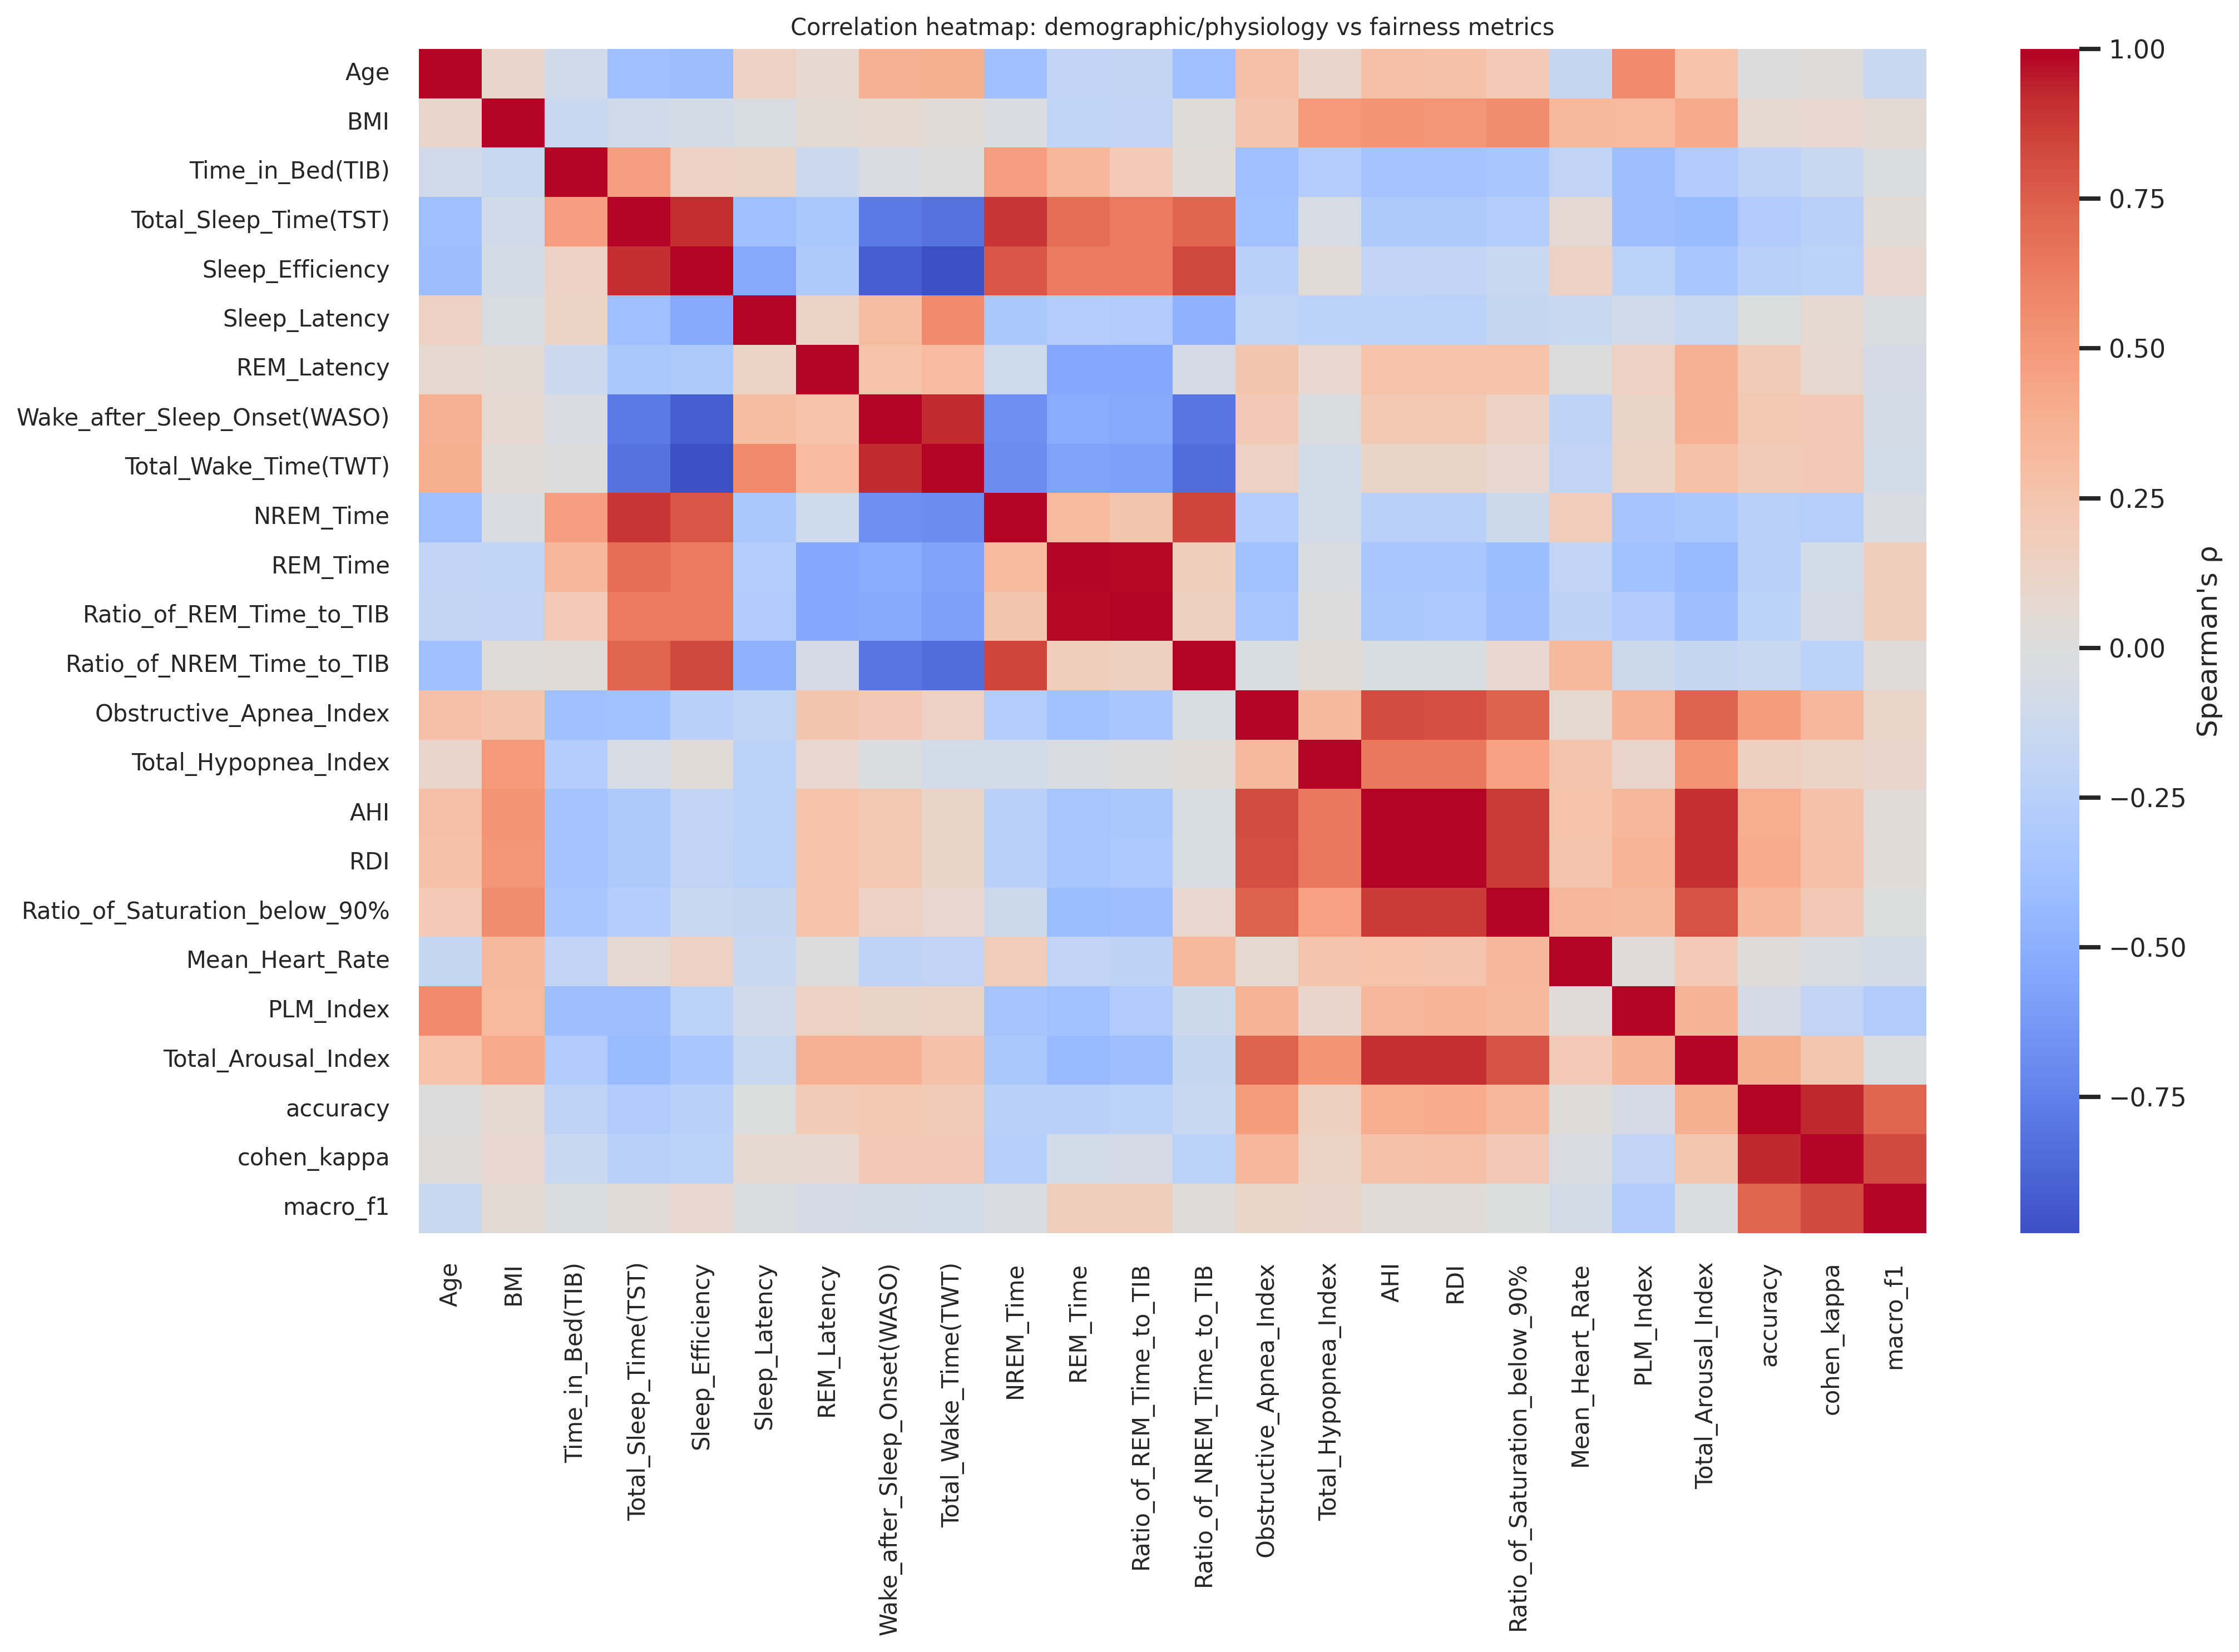


=== Spearman correlation summary (fairness trends) ===
                               accuracy  cohen_kappa  macro_f1
AHI                               0.392        0.271     0.040
Age                               0.006        0.013    -0.140
BMI                               0.070        0.086     0.051
Mean_Heart_Rate                   0.026       -0.040    -0.074
NREM_Time                        -0.247       -0.264    -0.027
Obstructive_Apnea_Index           0.485        0.340     0.108
PLM_Index                        -0.061       -0.190    -0.279
RDI                               0.398        0.277     0.044
REM_Latency                       0.198        0.080    -0.059
REM_Time                         -0.242       -0.084     0.168
Ratio_of_NREM_Time_to_TIB        -0.147       -0.231     0.015
Ratio_of_REM_Time_to_TIB         -0.223       -0.070     0.173
Ratio_of_Saturation_below_90%     0.341        0.213    -0.008
Sleep_Efficiency                 -0.237       -0.228     0.083

In [ ]:

# df_with_stage1: subject-level DataFrame (이미 구성된 상태)
# fairness 주요 metric
metrics = ['accuracy', 'cohen_kappa', 'macro_f1']

# 분석 대상 변수들 (Sex는 범주형)
features = [
    'Sex', 'Age', 'BMI', 'Time_in_Bed(TIB)', 'Total_Sleep_Time(TST)',
    'Sleep_Efficiency', 'Sleep_Latency', 'REM_Latency',
    'Wake_after_Sleep_Onset(WASO)', 'Total_Wake_Time(TWT)', 'NREM_Time',
    'REM_Time', 'Ratio_of_REM_Time_to_TIB', 'Ratio_of_NREM_Time_to_TIB',
    'Obstructive_Apnea_Index', 'Total_Hypopnea_Index', 'AHI', 'RDI',
    'Ratio_of_Saturation_below_90%', 'Mean_Heart_Rate', 'PLM_Index',
    'Total_Arousal_Index'
]

# 저장 디렉토리 생성
os.makedirs('images/fairness/stage1', exist_ok=True)

# 스타일 설정 (한 번만)
sns.set(style='whitegrid', context='talk', font_scale=0.67)
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------------------
# 1️⃣ 변수별 fairness scatter/regression plot (저장만)
# ---------------------------------------------------------------------
for m in metrics:
    for col in features:
        fig = plt.figure(figsize=(6,4), dpi=300)
        
        if col == 'Sex':
            sns.boxplot(x='Sex', y=m, data=df_with_stage1, palette='pastel')
            sns.stripplot(x='Sex', y=m, data=df_with_stage1, color='k', alpha=0.6)
            plt.title(f'{m} by Sex', fontsize=10)
        else:
            for sex in df_with_stage1['Sex'].unique():
                subset = df_with_stage1[df_with_stage1['Sex'] == sex]
                marker = 'o' if sex == 'Male' else '^'
                plt.scatter(subset[col], subset[m], alpha=0.6, s=40, 
                   marker=marker, label=sex)
            
            # sns.regplot(x=col, y=m, data=df_with_stage1,
            #        scatter=False, line_kws={'color':'red'})
            plt.legend(fontsize=10)
            plt.title(f'{m} vs {col}', fontsize=10)
        
        plt.xlabel(plt.gca().get_xlabel(), fontsize=10)
        plt.ylabel(plt.gca().get_ylabel(), fontsize=10)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        plt.tight_layout()
        plt.savefig(f'images/fairness/stage1/fairness_{m}_vs_{col}.png', dpi=300, bbox_inches='tight')
        plt.close()

# ---------------------------------------------------------------------
# 2️⃣ fairness 상관관계 heatmap
# ---------------------------------------------------------------------
corr_cols = [c for c in features if c != 'Sex'] + metrics
corr = df_with_stage1[corr_cols].corr(method='spearman')

fig = plt.figure(figsize=(14,10), dpi=300)
sns.heatmap(corr, cmap='coolwarm', center=0,
            cbar_kws={'label':"Spearman's ρ"}, annot=False)
plt.title('Correlation heatmap: demographic/physiology vs fairness metrics', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()
plt.savefig('fairness_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()

# ---------------------------------------------------------------------
# 3️⃣ fairness summary (정량 요약)
# ---------------------------------------------------------------------
summary = {}
for m in metrics:
    rhos = df_with_stage1[features].select_dtypes(include=np.number).corrwith(df_with_stage1[m], method='spearman')
    summary[m] = rhos.sort_values(ascending=False)
    
fairness_summary = pd.DataFrame(summary)
print("\n=== Spearman correlation summary (fairness trends) ===")
print(fairness_summary.round(3))

# Save the fairness summary table to CSV
fairness_summary.to_csv('fairness_correlation_summary.csv')

print("All plots saved with 300 dpi")


<ipython-input-37-3d7f13e0d374>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y=m, data=df_with_stage2, palette='pastel')
<ipython-input-37-3d7f13e0d374>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y=m, data=df_with_stage2, palette='pastel')
<ipython-input-37-3d7f13e0d374>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y=m, data=df_with_stage2, palette='pastel')


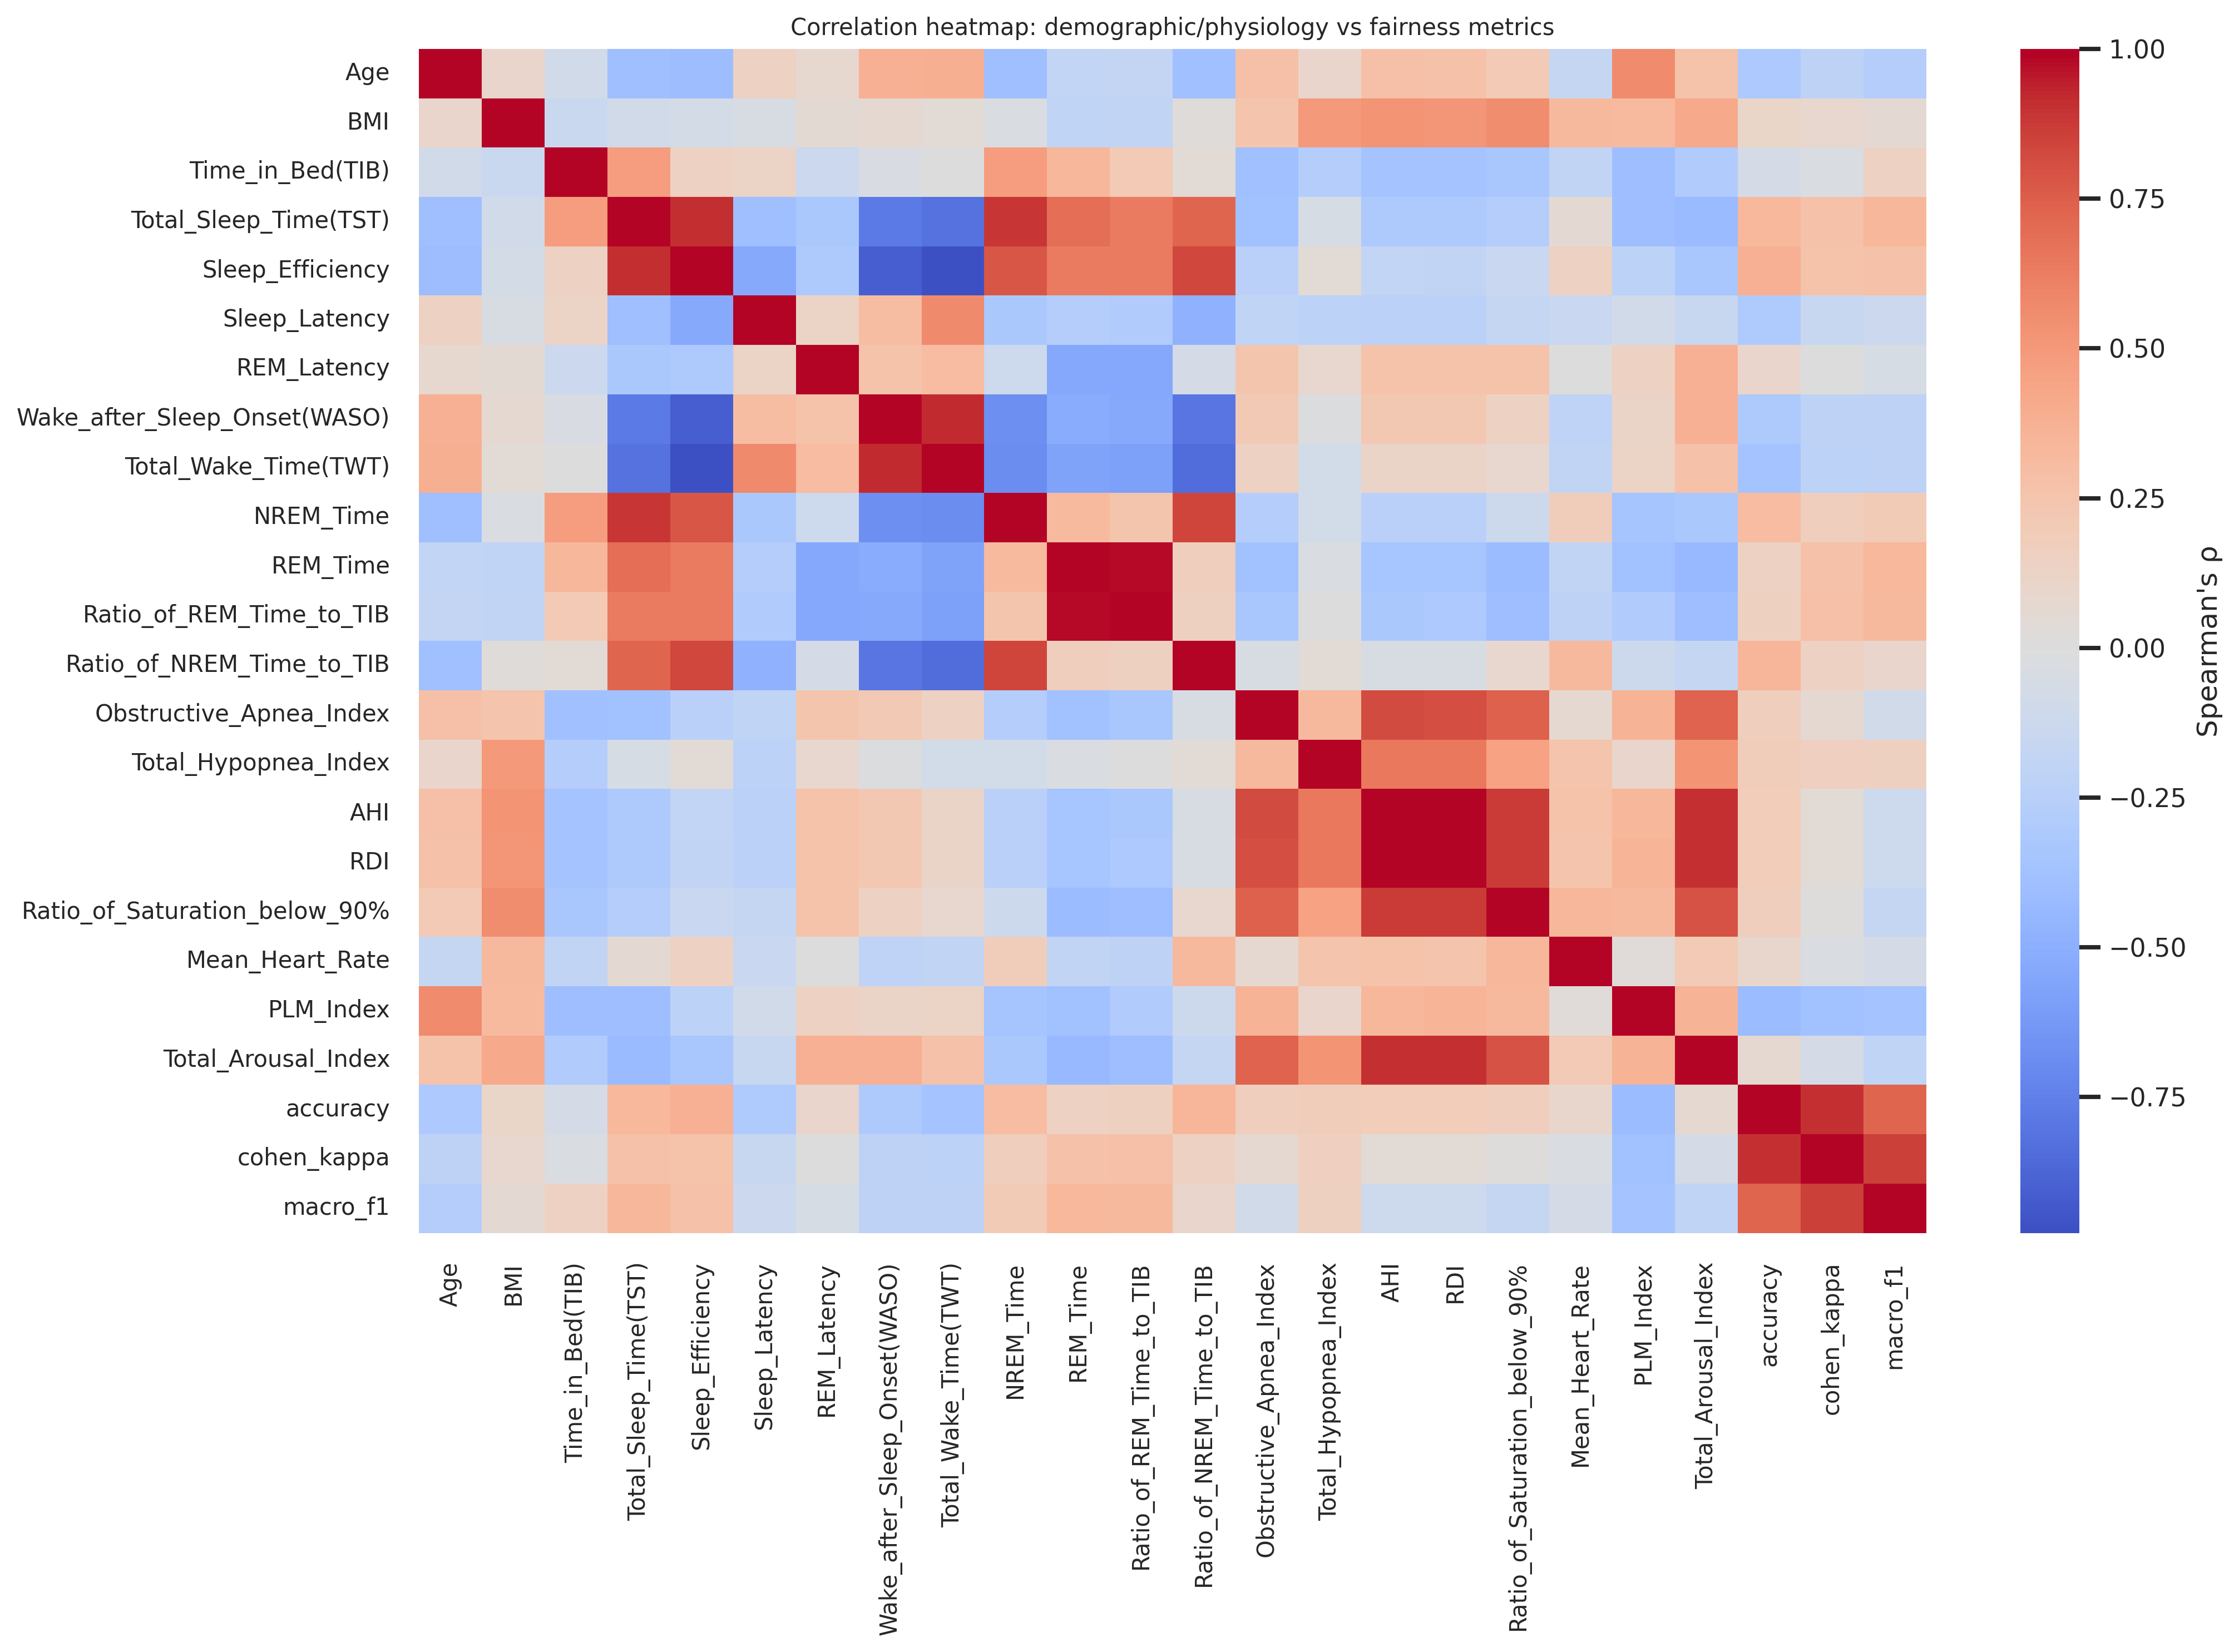


=== Spearman correlation summary (fairness trends) ===
                               accuracy  cohen_kappa  macro_f1
AHI                               0.187        0.044    -0.115
Age                              -0.313       -0.220    -0.270
BMI                               0.106        0.081     0.060
Mean_Heart_Rate                   0.094       -0.028    -0.073
NREM_Time                         0.307        0.166     0.201
Obstructive_Apnea_Index           0.169        0.070    -0.093
PLM_Index                        -0.418       -0.375    -0.364
RDI                               0.186        0.044    -0.115
REM_Latency                       0.099       -0.002    -0.053
REM_Time                          0.150        0.268     0.331
Ratio_of_NREM_Time_to_TIB         0.350        0.143     0.098
Ratio_of_REM_Time_to_TIB          0.154        0.275     0.322
Ratio_of_Saturation_below_90%     0.170        0.016    -0.171
Sleep_Efficiency                  0.376        0.262     0.273

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# df_with_stage2: subject-level DataFrame (이미 구성된 상태)
# fairness 주요 metric
metrics = ['accuracy', 'cohen_kappa', 'macro_f1']

# 분석 대상 변수들 (Sex는 범주형)
features = [
    'Sex', 'Age', 'BMI', 'Time_in_Bed(TIB)', 'Total_Sleep_Time(TST)',
    'Sleep_Efficiency', 'Sleep_Latency', 'REM_Latency',
    'Wake_after_Sleep_Onset(WASO)', 'Total_Wake_Time(TWT)', 'NREM_Time',
    'REM_Time', 'Ratio_of_REM_Time_to_TIB', 'Ratio_of_NREM_Time_to_TIB',
    'Obstructive_Apnea_Index', 'Total_Hypopnea_Index', 'AHI', 'RDI',
    'Ratio_of_Saturation_below_90%', 'Mean_Heart_Rate', 'PLM_Index',
    'Total_Arousal_Index'
]

# 저장 디렉토리 생성
os.makedirs('images/fairness/stage2', exist_ok=True)

# 스타일 설정 (한 번만)
sns.set(style='whitegrid', context='talk', font_scale=0.67)
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------------------
# 1️⃣ 변수별 fairness scatter/regression plot (저장만)
# ---------------------------------------------------------------------
for m in metrics:
    for col in features:
        fig = plt.figure(figsize=(6,4), dpi=300)
        
        if col == 'Sex':
            sns.boxplot(x='Sex', y=m, data=df_with_stage2, palette='pastel')
            sns.stripplot(x='Sex', y=m, data=df_with_stage2, color='k', alpha=0.6)
            plt.title(f'{m} by Sex', fontsize=10)
        else:
            for sex in df_with_stage2['Sex'].unique():
                subset = df_with_stage2[df_with_stage2['Sex'] == sex]
                marker = 'o' if sex == 'Male' else '^'
                plt.scatter(subset[col], subset[m], alpha=0.6, s=40, 
                   marker=marker, label=sex)
            
            # sns.regplot(x=col, y=m, data=df_with_stage2,
            #        scatter=False, line_kws={'color':'red'})
            plt.legend(fontsize=10)
            plt.title(f'{m} vs {col}', fontsize=10)
        
        plt.xlabel(plt.gca().get_xlabel(), fontsize=10)
        plt.ylabel(plt.gca().get_ylabel(), fontsize=10)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        plt.tight_layout()
        plt.savefig(f'images/fairness/stage2/fairness_{m}_vs_{col}.png', dpi=300, bbox_inches='tight')
        plt.close()

# ---------------------------------------------------------------------
# 2️⃣ fairness 상관관계 heatmap
# ---------------------------------------------------------------------
corr_cols = [c for c in features if c != 'Sex'] + metrics
corr = df_with_stage2[corr_cols].corr(method='spearman')

fig = plt.figure(figsize=(14,10), dpi=300)
sns.heatmap(corr, cmap='coolwarm', center=0,
            cbar_kws={'label':"Spearman's ρ"}, annot=False)
plt.title('Correlation heatmap: demographic/physiology vs fairness metrics', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()
plt.savefig('fairness_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()

# ---------------------------------------------------------------------
# 3️⃣ fairness summary (정량 요약)
# ---------------------------------------------------------------------
summary = {}
for m in metrics:
    rhos = df_with_stage2[features].select_dtypes(include=np.number).corrwith(df_with_stage2[m], method='spearman')
    summary[m] = rhos.sort_values(ascending=False)
    
fairness_summary = pd.DataFrame(summary)
print("\n=== Spearman correlation summary (fairness trends) ===")
print(fairness_summary.round(3))

# Save the fairness summary table to CSV
fairness_summary.to_csv('fairness_correlation_summary.csv')

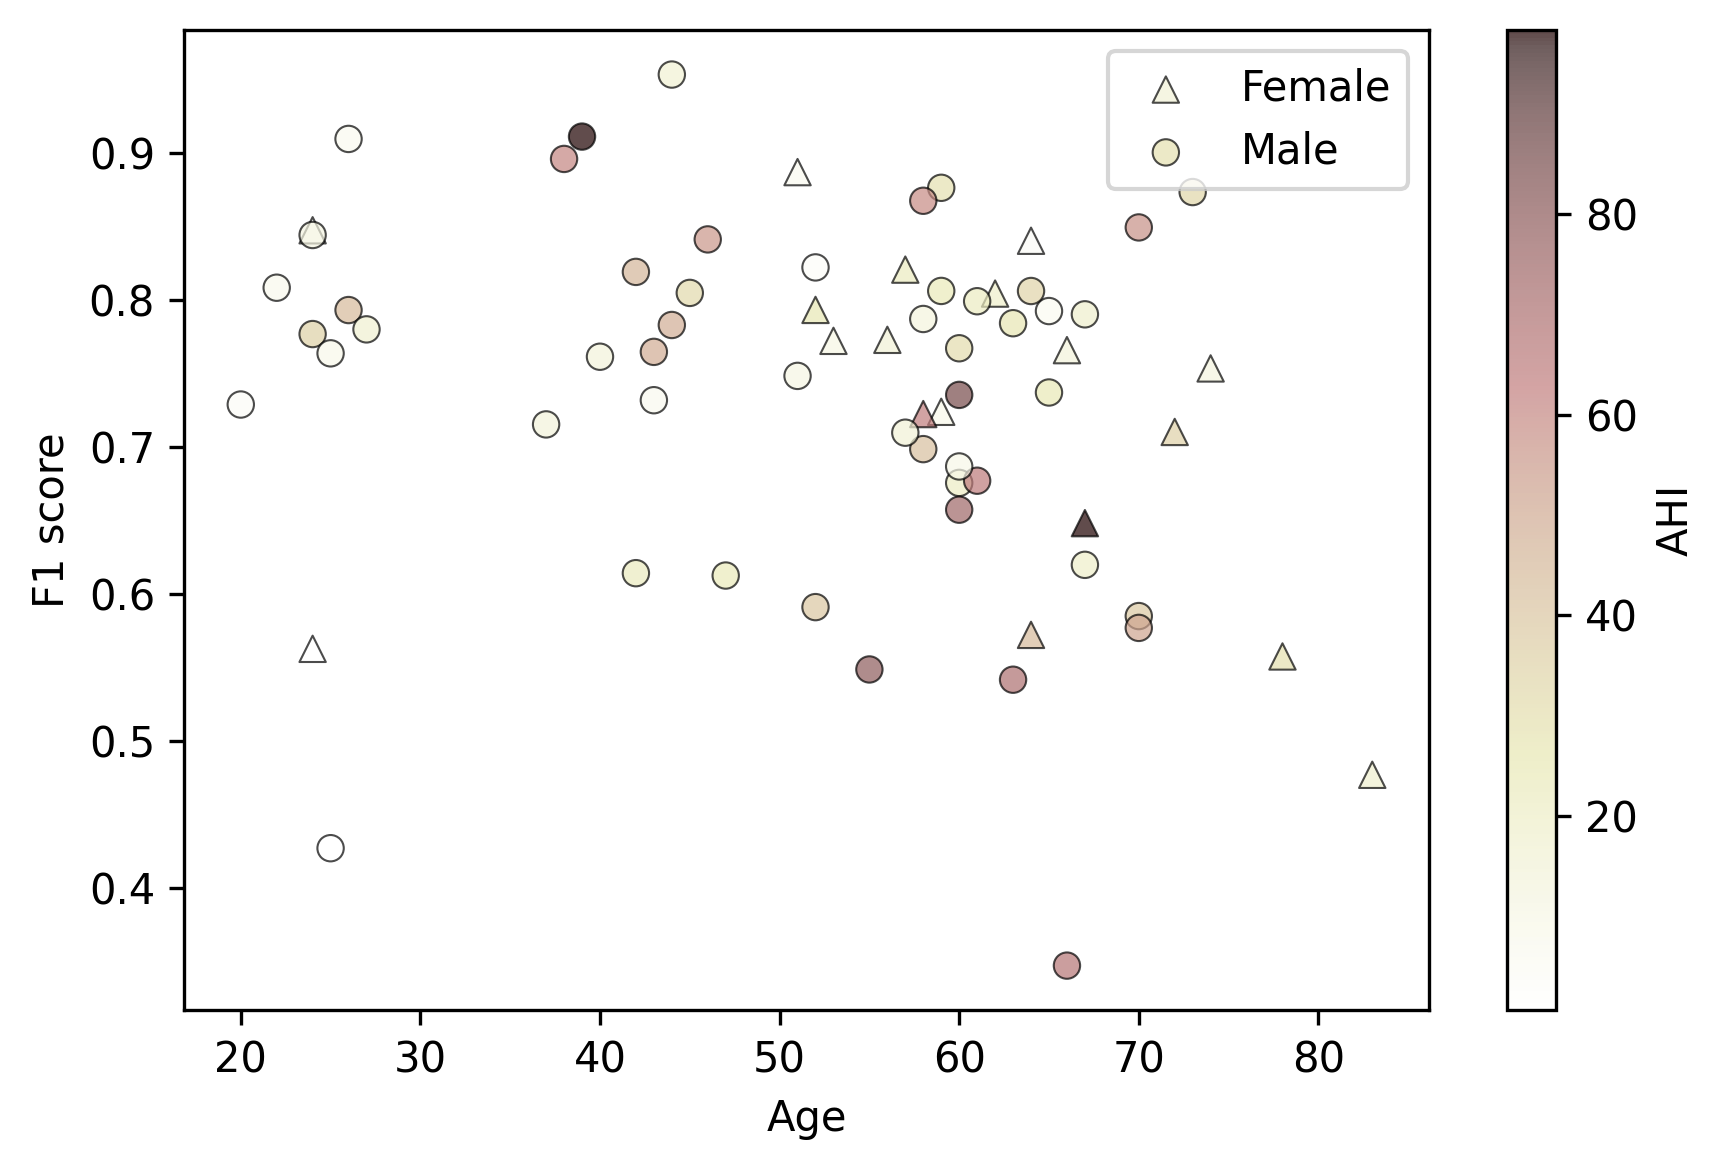

In [76]:
fig = plt.figure(figsize=(6,4), dpi=300)
# AHI 값을 기준으로 색상을 지정하기 위해 colormap 사용
scatters = []
for sex in df_with_stage2['Sex'].unique():
    subset = df_with_stage2[df_with_stage2['Sex'] == sex]
    marker = 'o' if sex == 'Male' else '^'
    
    # AHI 값에 따라 색상을 매핑
    scatter = plt.scatter(subset['Age'], subset['macro_f1'], 
                         c=subset['AHI'], cmap='pink_r', 
                         alpha=0.7, s=40, marker=marker, label=sex,
                         edgecolor='k', linewidth=0.5)
    scatters.append(scatter)

plt.legend(fontsize=10)
plt.colorbar(scatters[0], label='AHI')
# plt.title(f'F1 score vs Age', fontsize=10)
plt.xlabel('Age', fontsize=10)
plt.ylabel('F1 score', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(f'images/fairness/stage2/fairness_macro_f1_vs_Age.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

<ipython-input-5-0a6ae89e4262>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y='macro_f1', data=df_with_stage2, palette='pastel', ax=axes[1], showfliers=False,)


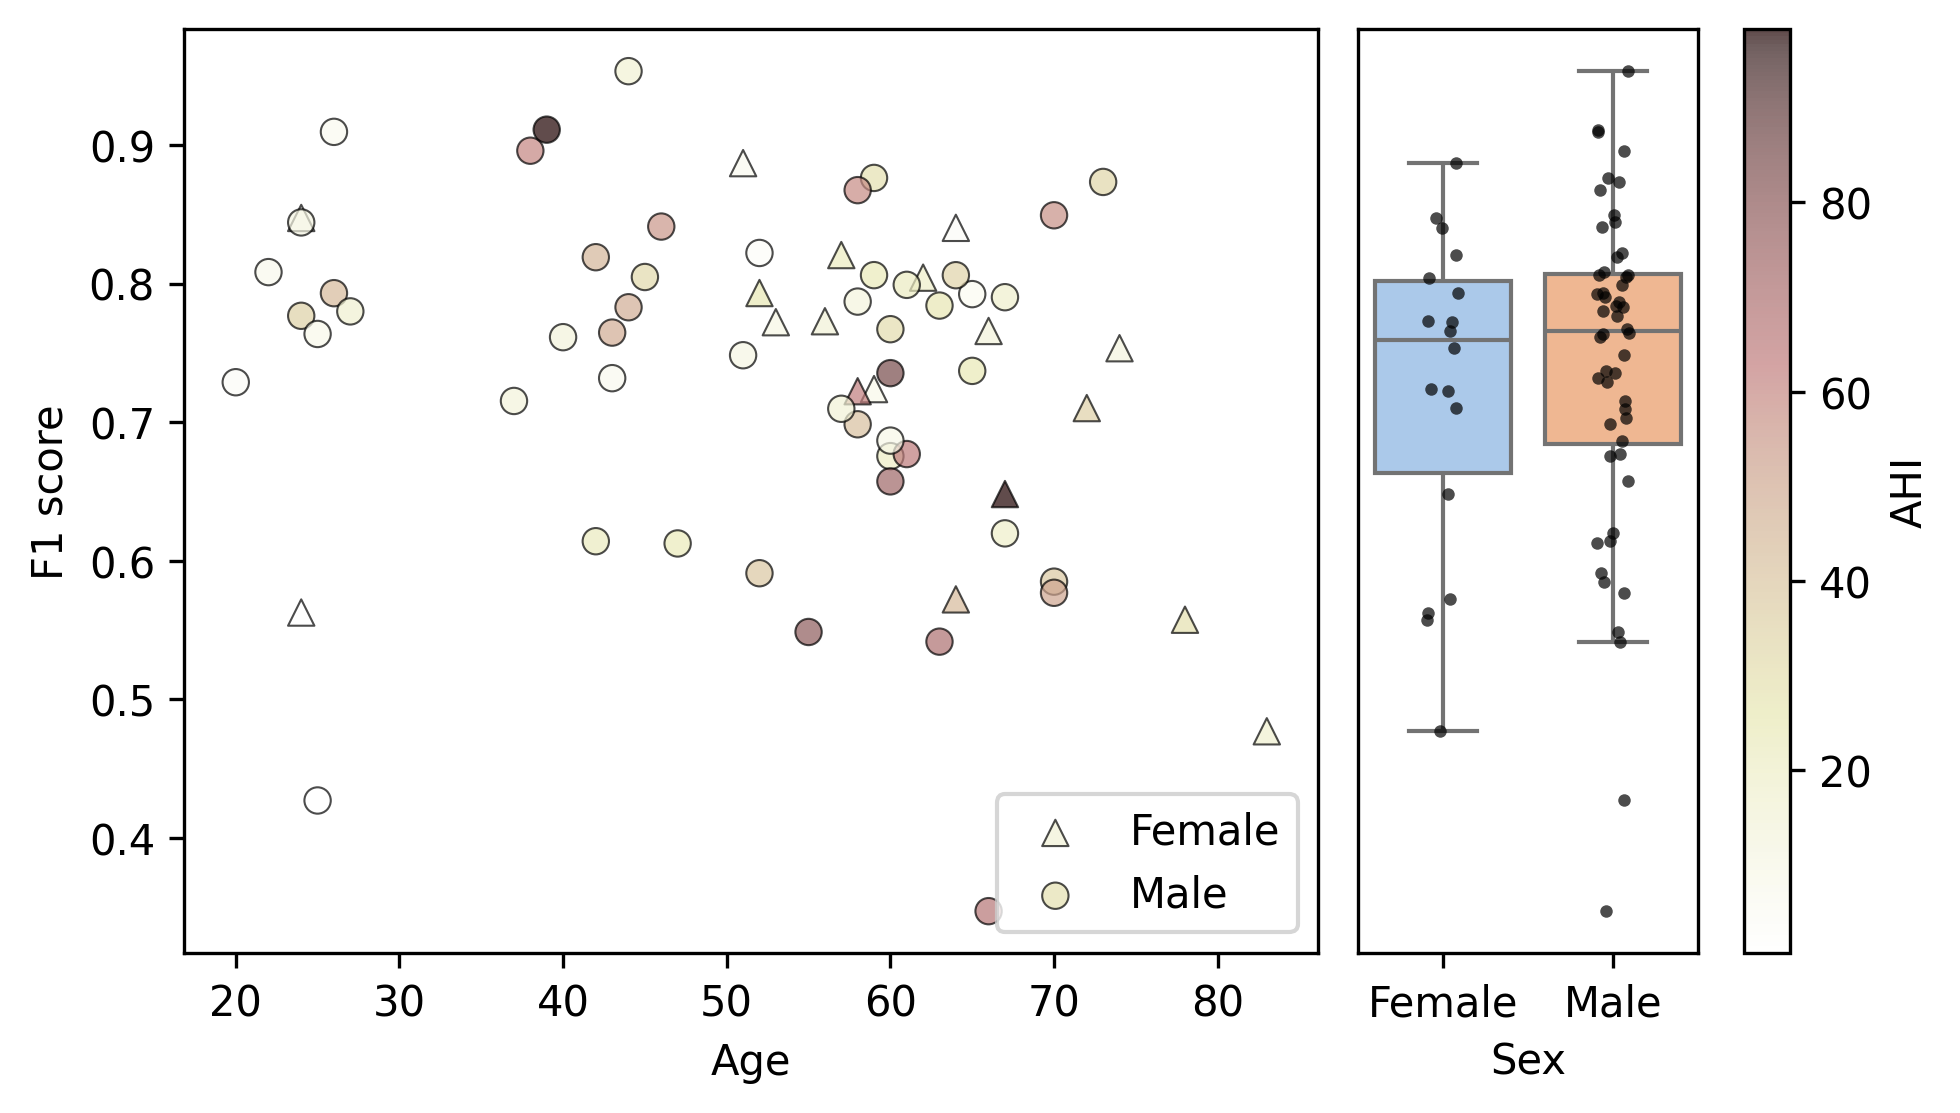

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4), dpi=300, gridspec_kw={'width_ratios': [5, 2]})

# Left: Scatter plot
scatters = []
for sex in df_with_stage2['Sex'].unique():
    subset = df_with_stage2[df_with_stage2['Sex'] == sex]
    marker = 'o' if sex == 'Male' else '^'
    
    scatter = axes[0].scatter(subset['Age'], subset['macro_f1'], 
                         c=subset['AHI'], cmap='pink_r', 
                         alpha=0.7, s=40, marker=marker, label=sex,
                         edgecolor='k', linewidth=0.5)
    scatters.append(scatter)

axes[0].legend(fontsize=10)
plt.colorbar(scatters[0], ax=axes[1], label='AHI', location='right', pad=0.1)
axes[0].set_xlabel('Age', fontsize=10)
axes[0].set_ylabel('F1 score', fontsize=10)
# axes[0].yaxis.set_label_position("right")
# axes[0].yaxis.tick_right()
axes[0].tick_params(labelsize=10)

# Right: Boxplot
sns.boxplot(x='Sex', y='macro_f1', data=df_with_stage2, palette='pastel', ax=axes[1], showfliers=False,)
sns.stripplot(x='Sex', y='macro_f1', data=df_with_stage2, color='k', alpha=0.7, size=3, ax=axes[1])
axes[1].set_xlabel('Sex', fontsize=10)
axes[1].set_ylabel('', fontsize=10)
axes[1].set_yticks([])  # Y축 눈금 제거
axes[1].tick_params(labelsize=10)

plt.subplots_adjust(wspace=0.05, hspace=0.35)
# plt.tight_layout()
plt.savefig(f'images/fairness/stage2/fairness_macro_f1_vs_Age_with_boxplot.pdf', bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4), dpi=300, gridspec_kw={'width_ratios': [5, 2]})

sex_order = ['Male', 'Female']  # 원하는 순서로 지정
# Left: Scatter plot
scatters = []
for sex in df_with_stage2['Sex'].unique():
    subset = df_with_stage2[df_with_stage2['Sex'] == sex]
    marker = 'o' if sex == 'Male' else '^'
    
    scatter = axes[0].scatter(subset['Age'], subset['macro_f1'], 
                         c=subset['AHI'], cmap='pink_r', 
                         alpha=0.7, s=40, marker=marker, label=sex,
                         edgecolor='k', linewidth=0.5)
    scatters.append(scatter)

axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1)
plt.colorbar(scatters[0], ax=axes[1], label='AHI', location='right', pad=0.1)
axes[0].set_xlabel('Age', fontsize=10)
axes[0].set_ylabel('F1 score', fontsize=10)
axes[0].tick_params(labelsize=10)

colors = sns.color_palette("pastel")

# Right: Boxplot - 색상 명시적으로 지정
sex_colors = {'Male': colors[0], 'Female': colors[1]}  # 원하는 색상으로 변경
sns.boxplot(x='Sex', y='macro_f1', data=df_with_stage2, 
            palette=sex_colors, order=sex_order, ax=axes[1], showfliers=False)
sns.stripplot(x='Sex', y='macro_f1', data=df_with_stage2, 
              color='k', alpha=0.7, size=3, ax=axes[1])
axes[1].set_xlabel('Sex', fontsize=10)
axes[1].set_ylabel('', fontsize=10)
axes[1].set_ylim(0, 1)
axes[1].set_yticks([])
axes[1].tick_params(labelsize=10)

plt.subplots_adjust(wspace=0.05, hspace=0.35)
plt.savefig(f'images/fairness/stage2/fairness_macro_f1_vs_Age_with_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

TypeError: __init__() got an unexpected keyword argument 'order'

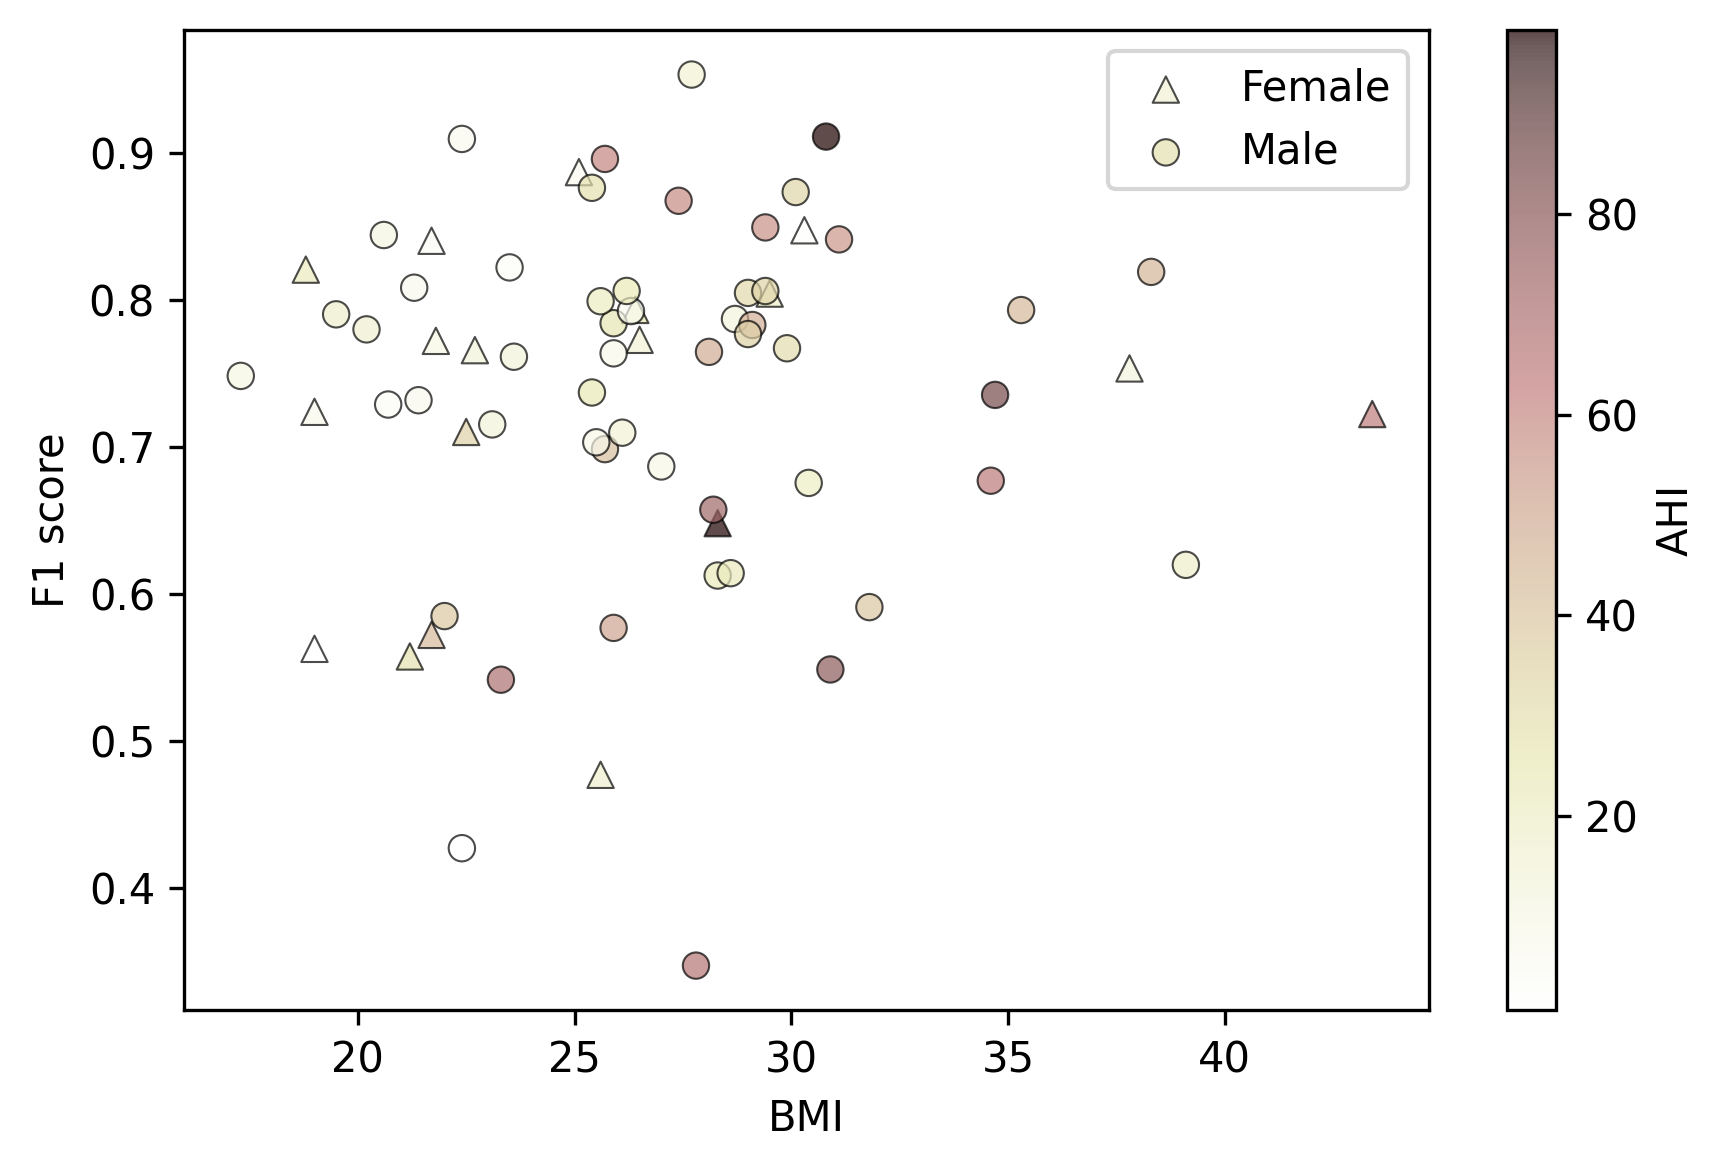

In [5]:
fig = plt.figure(figsize=(6,4), dpi=300)
# AHI 값을 기준으로 색상을 지정하기 위해 colormap 사용
scatters = []
for sex in df_with_stage2['Sex'].unique():
    subset = df_with_stage2[df_with_stage2['Sex'] == sex]
    marker = 'o' if sex == 'Male' else '^'
    
    # AHI 값에 따라 색상을 매핑
    scatter = plt.scatter(subset['BMI'], subset['macro_f1'], 
                         c=subset['AHI'], cmap='pink_r', 
                         alpha=0.7, s=40, marker=marker, label=sex,
                         edgecolor='k', linewidth=0.5)
    scatters.append(scatter)

plt.legend(fontsize=10)
plt.colorbar(scatters[0], label='AHI')
# plt.title(f'F1 score vs BMI', fontsize=10)
plt.xlabel('BMI', fontsize=10)
plt.ylabel('F1 score', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()
plt.savefig(f'images/fairness/stage2/fairness_macro_f1_vs_BMI.png', dpi=300, bbox_inches='tight')
plt.close()

In [1]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import os

prediction = Path("SleepVST_test_predictions.csv")

In [2]:
df = pd.read_csv(prediction)
print(df.head())

         subject_id  recording_idx  epoch_idx  ground_truth_label  \
0  A2020-EM-01-0245              0          0                   0   
1  A2020-EM-01-0245              0          1                   0   
2  A2020-EM-01-0245              0          2                   0   
3  A2020-EM-01-0245              0          3                   0   
4  A2020-EM-01-0245              0          4                   0   

  ground_truth_name  prediction_label prediction_name  
0              Wake                 0            Wake  
1              Wake                 0            Wake  
2              Wake                 0            Wake  
3              Wake                 0            Wake  
4              Wake                 0            Wake  


In [38]:
# GT 데이터프레임 생성
df_gt = df[['subject_id', 'recording_idx', 'epoch_idx', 'ground_truth_label', 'ground_truth_name']].copy()
df_gt['type'] = 'gt'
df_gt['label'] = df_gt['ground_truth_label']
df_gt['label_name'] = df_gt['ground_truth_name']
df_gt = df_gt.drop(['ground_truth_label', 'ground_truth_name'], axis=1)

# Prediction 데이터프레임 생성
df_pred = df[['subject_id', 'recording_idx', 'epoch_idx', 'prediction_label', 'prediction_name']].copy()
df_pred['type'] = 'pred'
df_pred['label'] = df_pred['prediction_label']
df_pred['label_name'] = df_pred['prediction_name']
df_pred = df_pred.drop(['prediction_label', 'prediction_name'], axis=1)

# 두 데이터프레임 결합
result_df = pd.concat([df_gt, df_pred], ignore_index=True)

# subject_id, recording_idx, epoch_idx, type 순으로 정렬
result_df = result_df.sort_values(['subject_id', 'recording_idx', 'epoch_idx', 'type']).reset_index(drop=True)

print(result_df.head(10))
df = result_df.copy()
# 결과 저장 (필요시)
# result_df.to_csv('transformed_data.csv', index=False)

         subject_id  recording_idx  epoch_idx  type  label label_name
0  A2019-EM-01-0021             41          0    gt      0       Wake
1  A2019-EM-01-0021             41          0  pred      0       Wake
2  A2019-EM-01-0021             41          1    gt      0       Wake
3  A2019-EM-01-0021             41          1  pred      0       Wake
4  A2019-EM-01-0021             41          2    gt      0       Wake
5  A2019-EM-01-0021             41          2  pred      0       Wake
6  A2019-EM-01-0021             41          3    gt      0       Wake
7  A2019-EM-01-0021             41          3  pred      0       Wake
8  A2019-EM-01-0021             41          4    gt      0       Wake
9  A2019-EM-01-0021             41          4  pred      0       Wake


In [39]:
# 하나의 recording만 선택 (원하면 그룹 반복도 가능)
sid = "A2019-EM-01-0021"
rid = 41

df_sub = df[(df["subject_id"] == sid) & (df["recording_idx"] == rid)]
df_gt = df_sub[df_sub["type"] == "gt"].sort_values("epoch_idx")
df_pred = df_sub[df_sub["type"] == "pred"].sort_values("epoch_idx")

gt = df_gt["label"].to_numpy()
pred = df_pred["label"].to_numpy()

epochs = df_gt["epoch_idx"].to_numpy()

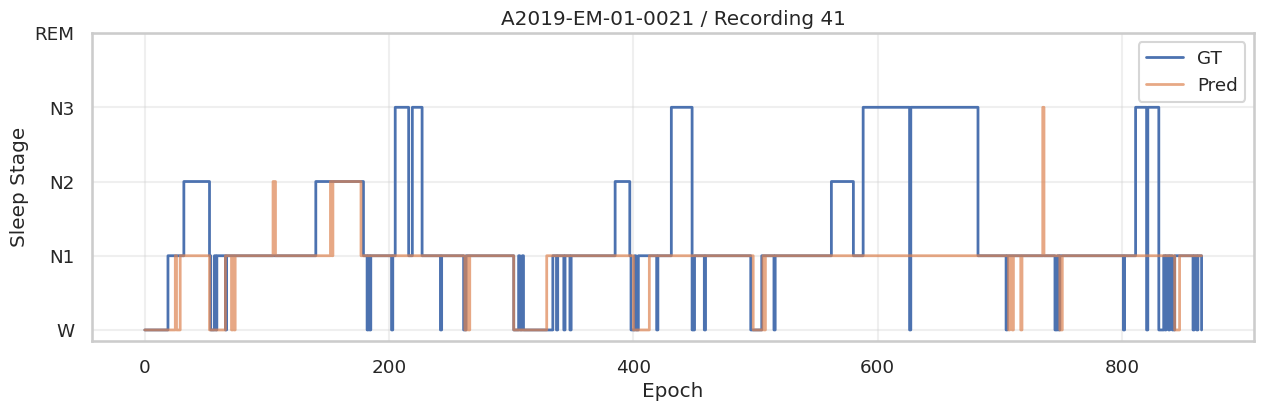

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.step(epochs, gt, where="post", label="GT", linewidth=2)
plt.step(epochs, pred, where="post", label="Pred", linewidth=2, alpha=0.7)

plt.yticks([0,1,2,3,4], ["W","N1","N2","N3","REM"])
plt.xlabel("Epoch")
plt.ylabel("Sleep Stage")
plt.legend()
plt.grid(alpha=0.3)
plt.title(f"{sid} / Recording {rid}")
plt.show()

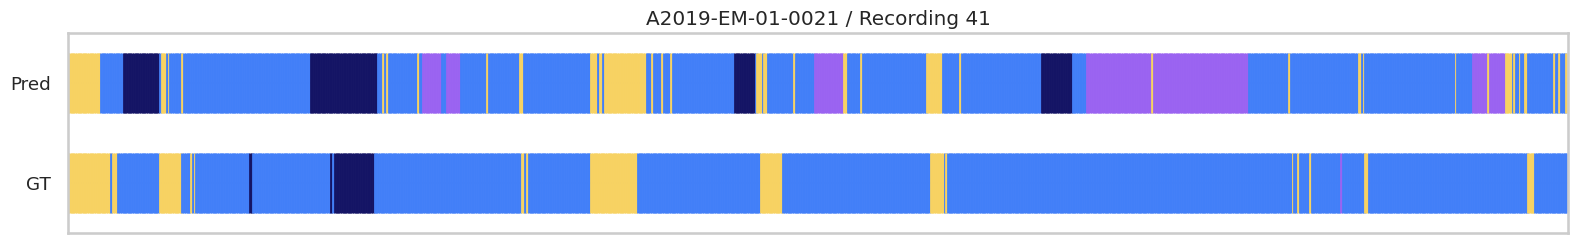

In [52]:
import numpy as np

colors_255 = np.array([
    [247, 210,  98],   # color Wake
    [ 66, 127, 248],   # color Light
    [ 20,  20, 101],   # color Deep
    [154,  99, 241],   # color REM
])

colors_norm = colors_255 / 255.0
colors = {
    0: colors_norm[0],
    1: colors_norm[1],
    2: colors_norm[2],
    3: colors_norm[3],
}
fig, ax = plt.subplots(figsize=(15, 2))
# Pred (lower row)
for i, s in zip(epochs, pred):
    ax.vlines(i, 0.2, 0.8, color=colors[s], linewidth=2)
    
# GT (upper row)
for i, s in zip(epochs, gt):
    ax.vlines(i, 1.2, 1.8, color=colors[s], linewidth=2)

ax.set_ylim(0, 2)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["GT", "Pred"])
ax.set_xlim(epochs[0], epochs[-1]+1)
ax.margins(x=0, y=0)
ax.set_xticks([])
ax.set_yticks([0.5, 1.5])

plt.tight_layout()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.title(f"{sid} / Recording {rid}")
plt.show()

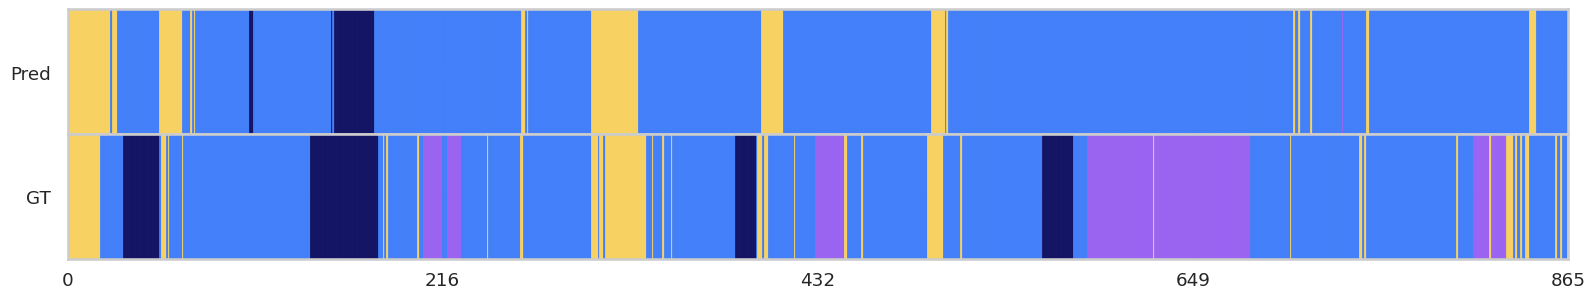

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 1, figsize=(15, 2.5),
    sharex=True, sharey=False,
    gridspec_kw={"height_ratios": [1, 1]}  # 위: Pred / 아래: GT
)

ax_pred, ax_gt = axes

# -------------------------
# Pred (위쪽)
# -------------------------
for i, s in zip(epochs, pred):
    ax_pred.vlines(i, 0, 1, color=colors[s], linewidth=2)

ax_pred.set_ylim(0, 1)
ax_pred.set_yticks([0.5])
ax_pred.set_yticklabels(["Pred"])
ax_pred.set_xticks([])

# -------------------------
# GT (아래쪽)
# -------------------------
for i, s in zip(epochs, gt):
    ax_gt.vlines(i, 0, 1, color=colors[s], linewidth=2)

ax_gt.set_ylim(0, 1)
ax_gt.set_yticks([0.5])
ax_gt.set_yticklabels(["GT"])

# xtick 5개만 표시
ticks = np.linspace(min(epochs), max(epochs), 5).round().astype(int)
ax_gt.set_xticks(ticks)
ax_gt.set_xticklabels(ticks)
ax_gt.tick_params(
    axis='x',
    which='both',
    length=5,      # tick 길이 (기본 3.5보다 길게)
    width=1,       # tick 두께
    direction='out'
)
# -------------------------
# 전체 레이아웃 조정 (빈공간 제거)
# -------------------------
for ax in axes:
    ax.set_xlim(min(epochs), max(epochs))
    ax.margins(0)

plt.tight_layout(pad=0)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0)

plt.show()

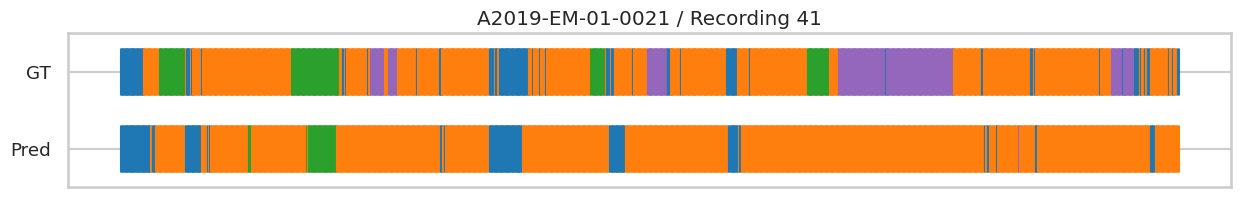

In [45]:
fig, ax = plt.subplots(figsize=(15,2))

for i, s in zip(epochs, gt):
    ax.vlines(i, 1.2, 1.8, color=colors[s])

for i, s in zip(epochs, pred):
    ax.vlines(i, 0.2, 0.8, color=colors[s])

ax.set_ylim(0,2)
ax.set_yticks([0.5,1.5])
ax.set_yticklabels(["Pred","GT"])
ax.set_xticks([])
plt.title(f"{sid} / Recording {rid}")
plt.show()

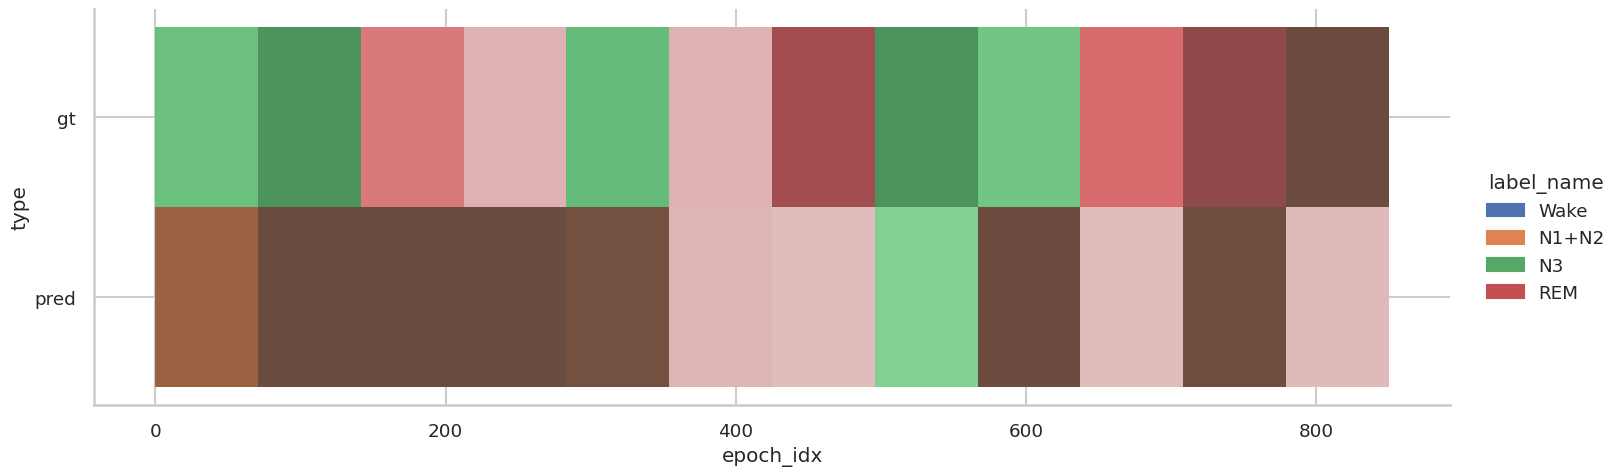

In [31]:
sns.displot(data=result_df[result_df['subject_id'] == 'A2020-EM-01-0245'], x='epoch_idx', y='type', hue='label_name', aspect=3, bins='auto')
sns.set_theme(style='whitegrid', context='talk', font_scale=0.8)
plt.show()

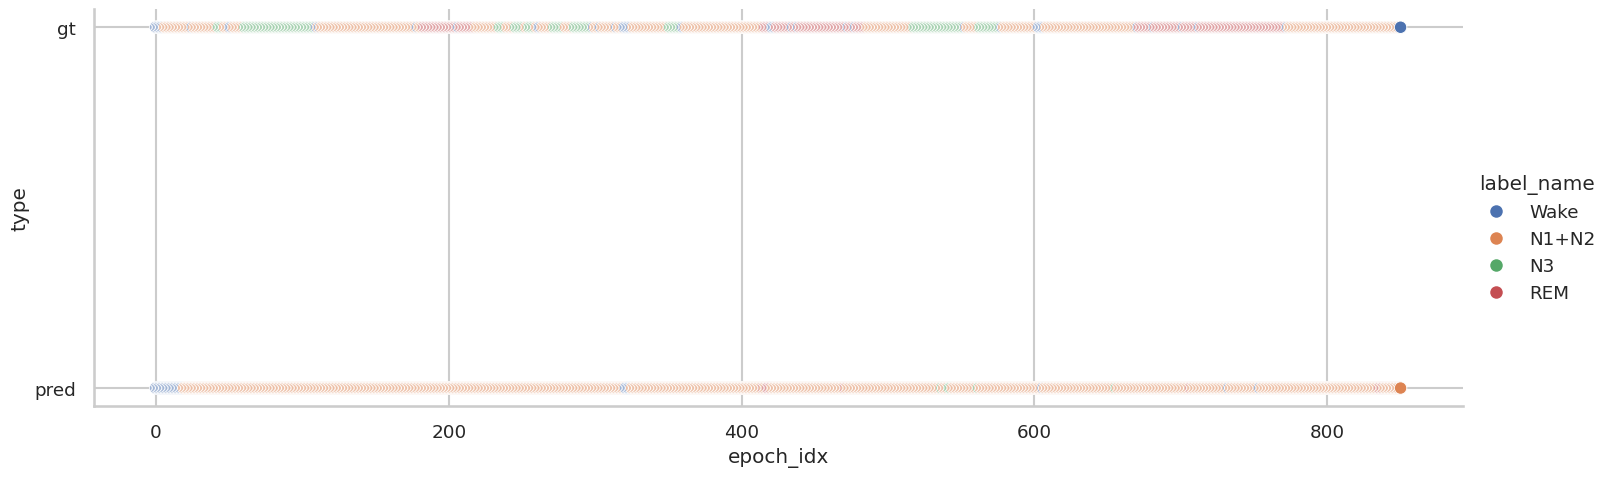

In [36]:
sns.relplot(data=result_df[result_df['subject_id'] == 'A2020-EM-01-0245'], x='epoch_idx', y='type', hue='label_name', aspect=3)
plt.show()

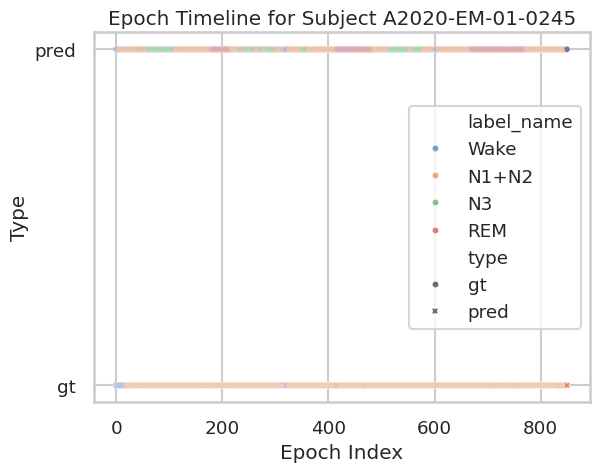

In [37]:
sns.scatterplot(data=result_df[result_df['subject_id'] == 'A2020-EM-01-0245'], x='epoch_idx', y='type', hue='label_name', style='type', s=20, alpha=0.7)
xticks = {epoch: i for i, epoch in enumerate(sorted(result_df['epoch_idx'].unique()))}
yticks = {'gt': 1, 'pred': 0}  # Y축 위치 지정
plt.yticks(list(yticks.values()), list(yticks.keys()))
plt.xlabel('Epoch Index')
plt.ylabel('Type')
plt.title('Epoch Timeline for Subject A2020-EM-01-0245')
plt.show()

In [6]:
crashes = sns.load_dataset("car_crashes")
print(crashes.head())

   total  speeding  alcohol  not_distracted  no_previous  ins_premium  \
0   18.8     7.332    5.640          18.048       15.040       784.55   
1   18.1     7.421    4.525          16.290       17.014      1053.48   
2   18.6     6.510    5.208          15.624       17.856       899.47   
3   22.4     4.032    5.824          21.056       21.280       827.34   
4   12.0     4.200    3.360          10.920       10.680       878.41   

   ins_losses abbrev  
0      145.08     AL  
1      133.93     AK  
2      110.35     AZ  
3      142.39     AR  
4      165.63     CA  


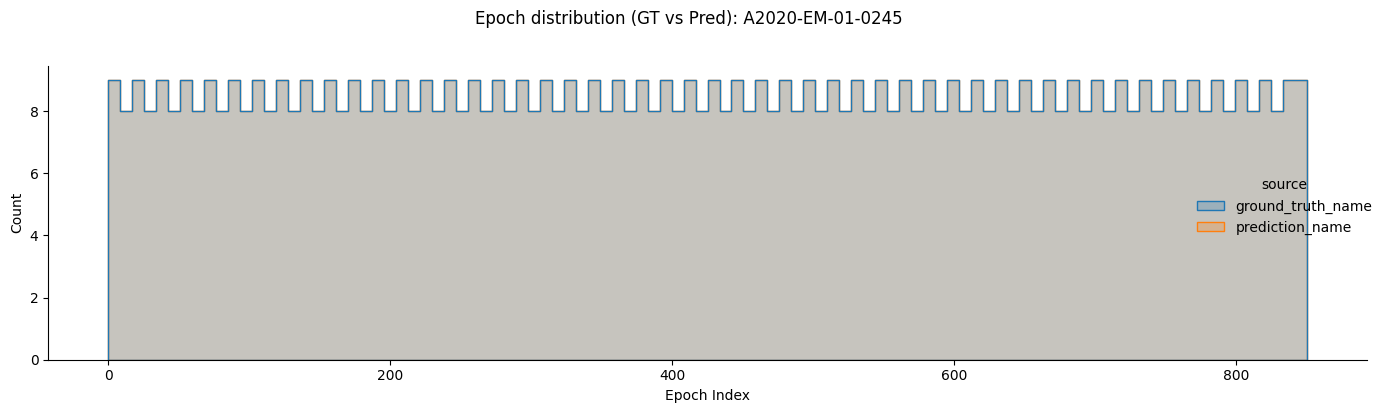

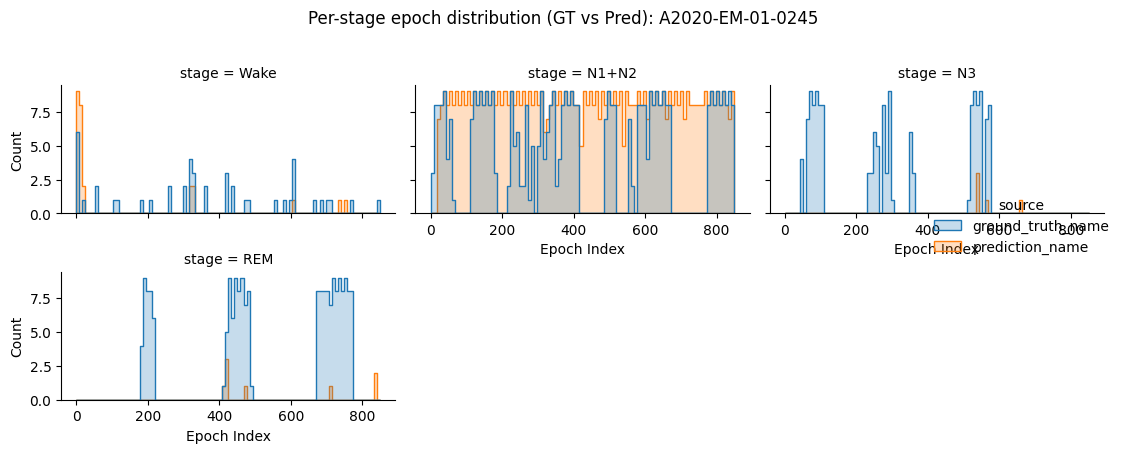

In [3]:
# ==== Ground truth vs prediction epoch 분포 (displot) ====
import seaborn as sns

# 1) 특정 대상 선택 (원하면 제거)
target_id = 'A2020-EM-01-0245'
df_sub = df[df['subject_id'] == target_id].copy()

# 2) long 형태로 변환
df_long = df_sub.melt(
    id_vars=['epoch_idx'],
    value_vars=['ground_truth_name', 'prediction_name'],
    var_name='source',
    value_name='stage'
)

# 3) epoch 분포를 히스토그램으로 (ground vs pred 겹침)
# bins 개수는 전체 epoch 길이에 맞게 조정
n_epochs = df_sub['epoch_idx'].max() + 1
bins = min(100, n_epochs)  # 너무 많으면 줄임

g = sns.displot(
    data=df_long,
    x='epoch_idx',
    hue='source',
    multiple='layer',       # 겹쳐 그리기
    element='step',         # 테두리형
    bins=bins,
    height=4,
    aspect=3
)
g.set_axis_labels("Epoch Index", "Count")
g.fig.suptitle(f"Epoch distribution (GT vs Pred): {target_id}", y=1.02)
plt.tight_layout()
plt.savefig(f'images/fairness/stage2/epoch_distribution_{target_id}.png', dpi=300, bbox_inches='tight')
plt.show()

# 4) (선택) 각 수면단계별 epoch 위치 분포를 보고 싶다면 facet 사용
# 단계별로 epoch 위치에 어떤 분포로 등장하는지 확인
g2 = sns.displot(
    data=df_long,
    x='epoch_idx',
    hue='source',
    col='stage',
    col_wrap=3,
    multiple='layer',
    element='step',
    bins=bins,
    height=2.2,
    aspect=1.4
)
g2.set_axis_labels("Epoch Index", "Count")
g2.fig.suptitle(f"Per-stage epoch distribution (GT vs Pred): {target_id}", y=1.02)
plt.tight_layout()
plt.savefig(f'images/fairness/stage2/epoch_distribution_per_stage_{target_id}.png', dpi=300, bbox_inches='tight')
plt.show()

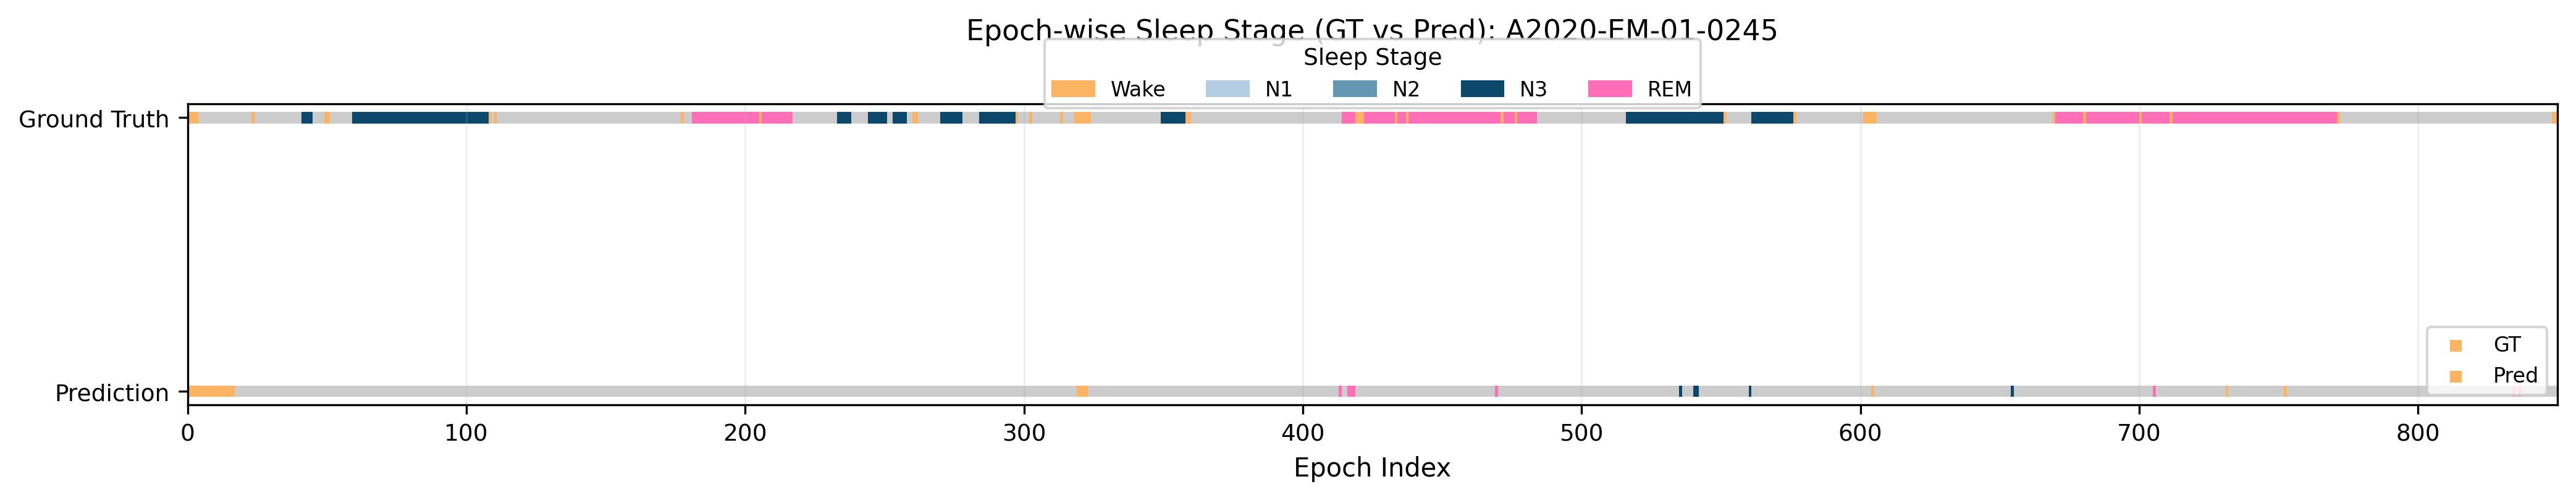

In [ ]:

# 수면 단계 색상 매핑 (필요시 수정)
stage_palette = {
    'Wake': '#FDB462',
    'N1':   '#B3CDE3',
    'N2':   '#6497B1',
    'N3':   '#0B486B',
    'REM':  '#FF6EB6'
}
# 누락 단계 대비 fallback
default_color = '#CCCCCC'

# 색상 벡터 생성
gt_colors = df_sub['ground_truth_name'].map(lambda x: stage_palette.get(x, default_color))
pred_colors = df_sub['prediction_name'].map(lambda x: stage_palette.get(x, default_color))

fig, ax = plt.subplots(figsize=(14, 2.8), dpi=300)

# GT (y=1) / Prediction (y=0) 산점도 (marker='s'로 셀 형태)
ax.scatter(df_sub['epoch_idx'], np.ones(len(df_sub)), c=gt_colors, s=20, marker='s', linewidths=0, label='GT')
ax.scatter(df_sub['epoch_idx'], np.zeros(len(df_sub)), c=pred_colors, s=20, marker='s', linewidths=0, label='Pred')

# y 축 설정
ax.set_yticks([0, 1])
ax.set_yticklabels(['Prediction', 'Ground Truth'])
ax.set_xlabel('Epoch Index', fontsize=10)
ax.set_ylabel('', fontsize=10)

# 눈금/레이아웃
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.set_xlim(df_sub['epoch_idx'].min(), df_sub['epoch_idx'].max())
ax.grid(axis='x', alpha=0.2)

# 단계 색상 범례 (stage별)
import matplotlib.patches as mpatches
stage_handles = [mpatches.Patch(color=col, label=stage) for stage, col in stage_palette.items()]
leg1 = ax.legend(handles=stage_handles, title='Sleep Stage', fontsize=8, title_fontsize=9,
                 loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=len(stage_palette))
ax.add_artist(leg1)
ax.legend(loc='lower right', fontsize=8)

ax.set_title(f'Epoch-wise Sleep Stage (GT vs Pred): {target_id}', fontsize=11, pad=25)

plt.tight_layout()
plt.savefig(f'images/fairness/stage2/epoch_timeline_{target_id}.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
diamonds = sns.load_dataset("diamonds")
print(diamonds.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
